<a href="https://colab.research.google.com/github/mhdhaikal22/data-science-2026/blob/main/Pertemuan10_%5BMUHAMMAD_HAIKAL%5D_%5B240401010269%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pertemuan 10 - Algoritma Klasifikasi (Bagian 2)

**Nama:** Muhammad Haikal  
**NIM:** 240401010269  
**Kelas:** IF401

In [ ]:
# Muat dan Eksplorasi Data

import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
print(df["Churn"].value_counts(normalize=True))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [ ]:
# Preprocessing

from sklearn.model_selection import train_test_split
import pandas as pd

# Encoding fitur kategorikal
X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)
y = df["Churn"]

# Data splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
# Latih Model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

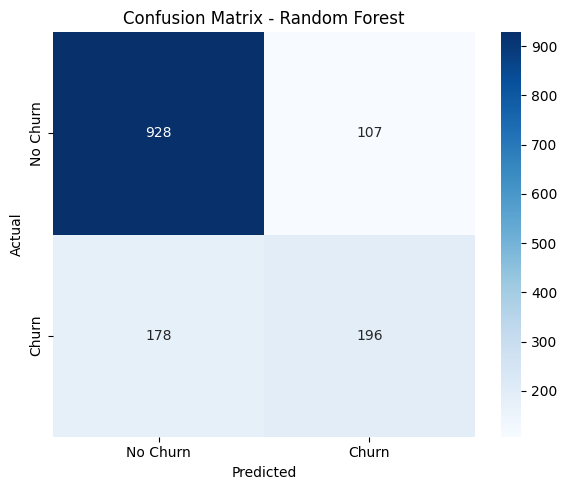

Accuracy : 0.798
Precision: 0.647
Recall   : 0.524
F1-Score : 0.579
ROC-AUC  : 0.834

Classification Report
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
# Evaluasi

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)

import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn','Churn'],
    yticklabels=['No Churn','Churn']
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"Accuracy : {accuracy_score(y_test,y_pred):.3f}")
print(f"Precision: {precision_score(y_test,y_pred,pos_label='Yes'):.3f}")
print(f"Recall   : {recall_score(y_test,y_pred,pos_label='Yes'):.3f}")
print(f"F1-Score : {f1_score(y_test,y_pred,pos_label='Yes'):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test,y_proba):.3f}")

print("\nClassification Report")
print(classification_report(y_test,y_pred))

Dataset Customer Churn merupakan dataset yang tidak seimbang (imbalanced), sehingga Accuracy saja tidak cukup untuk mengevaluasi performa model. Pada hasil pengujian ini, model memperoleh Accuracy sebesar 79,8%, namun Recall hanya 52,4%, yang menunjukkan bahwa masih terdapat pelanggan yang benar-benar churn tetapi belum berhasil dideteksi oleh model.

Oleh karena itu, Recall menjadi metrik yang sangat penting karena menunjukkan kemampuan model dalam mengidentifikasi pelanggan yang berpotensi churn. Selain itu, F1-Score memberikan keseimbangan antara Precision dan Recall sehingga lebih representatif untuk mengevaluasi performa model pada dataset yang tidak seimbang.

In [ ]:
# Prediksi Probabilitas dan Simpulkan

import pandas as pd

# Prediksi probabilitas churn
proba_churn = rf.predict_proba(X_test)[:, 1]

# Tampilkan beberapa contoh probabilitas
print("Probabilitas churn (10 data pertama):")
print(proba_churn[:10])

# Gabungkan hasil ke dalam DataFrame
hasil = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Prob_Churn": proba_churn
})

hasil.head(10)

Probabilitas churn (10 data pertama):
[0.00333333 0.63666667 0.07333333 0.37666667 0.01666667 0.56666667
 0.46333333 0.03       0.00333333 0.53      ]


,Actual,Predicted,Prob_Churn
0,No,No,0.003333
1,No,Yes,0.636667
2,No,No,0.073333
3,No,No,0.376667
4,No,No,0.016667
5,No,Yes,0.566667
6,No,No,0.463333
7,No,No,0.030000
8,No,No,0.003333
9,Yes,Yes,0.530000


Model Random Forest yang dibangun mampu memprediksi probabilitas churn pelanggan menggunakan fungsi predict_proba. Berdasarkan evaluasi, model memiliki performa yang cukup baik dengan ROC-AUC sekitar 0.83 yang menunjukkan kemampuan pemisahan kelas yang baik. Namun, recall pada kelas churn masih belum optimal sehingga beberapa pelanggan berisiko churn belum terdeteksi. Model masih dapat ditingkatkan dengan tuning parameter atau penyesuaian threshold prediksi.

## Kesimpulan

Pada praktikum ini saya mempelajari penerapan algoritma Random Forest sebagai salah satu metode *ensemble learning* untuk melakukan klasifikasi pada dataset Customer Churn. Saya melakukan preprocessing data, melatih model, mengevaluasi performanya menggunakan Confusion Matrix, Accuracy, Precision, Recall, F1-Score, dan ROC-AUC, serta menganalisis probabilitas pelanggan yang berpotensi melakukan churn.

Temuan utama dari praktikum ini adalah bahwa Random Forest mampu memberikan performa klasifikasi yang cukup baik dalam membedakan pelanggan yang churn dan tidak churn. Selain itu, hasil evaluasi menunjukkan bahwa pada dataset yang tidak seimbang (*imbalanced*), metrik seperti Recall, F1-Score, dan ROC-AUC memberikan gambaran performa model yang lebih representatif dibandingkan hanya melihat Accuracy. Praktikum ini masih menggunakan satu algoritma *ensemble learning*, sehingga pada pertemuan berikutnya akan dipelajari metode *unsupervised learning* untuk menemukan pola dan kelompok data tanpa menggunakan label.